In [ ]:
import pandas as pd

In [ ]:
!pip install beautifulsoup4 requests

##Task-1:
 Web Scraping

In [8]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

titles, prices, availabilities = [], [], []
books = soup.find_all('article', class_='product_pod')

for book in books:
    titles.append(book.h3.a['title']) # Fixed typo
    prices.append(book.find('p', class_='price_color').text)
    availabilities.append(book.find('p', class_='instock availability').text.strip())

df = pd.DataFrame({'Title': titles, 'Price': prices, 'Availability': availabilities})
df.to_csv('scraped_books.csv', index=False)
print("Dataset created successfully!")
#Data Cleaning and Preparation
df['Price'] = df['Price'].astype(str).str.replace('Â£', '').astype(float)

Dataset created successfully!


## Task-2:
Exploratory Data Analysis (EDA)

In [9]:
df = pd.DataFrame({'Title': titles, 'Price': prices, 'Availability': availabilities})
df.to_csv('scraped_books.csv', index=False)
df['Price'] = df['Price'].astype(str).str.replace('Â£', '').astype(float)
print("--- Data Summary ---")
print(df.describe())

--- Data Summary ---
           Price
count  20.000000
mean   38.048500
std    15.135231
min    13.990000
25%    22.637500
50%    41.380000
75%    51.865000
max    57.250000


##Task-3:
Data Visualization

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

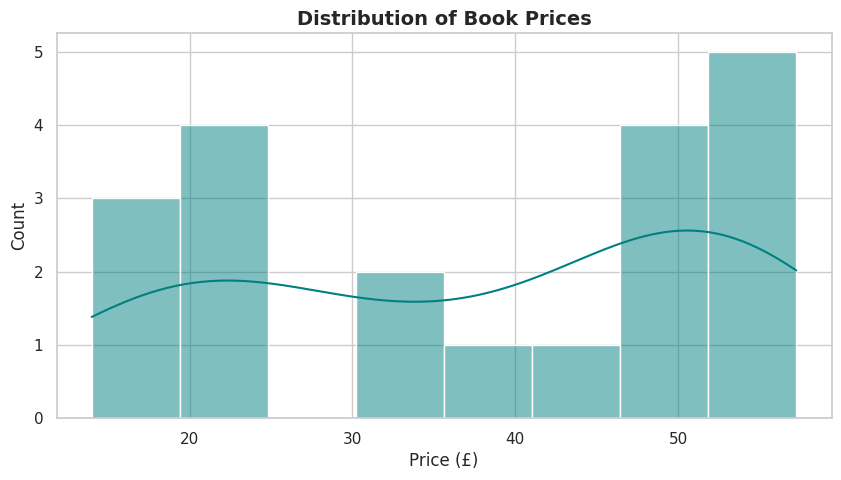

In [12]:
df['Price'] = df['Price'].astype(str).str.replace('Â£', '').astype(float)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=8, kde=True, color='teal')
plt.title('Distribution of Book Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.show()